In [1]:
import pandas as pd
import numpy as np
import yfinance as yf

ticker='RELIANCE.NS'
## getting data from yfinance
df=yf.download('RELIANCE.NS',start='2018-01-01',end='2026-05-01',progress=False)
print(df.tail())

/var/folders/j2/gw4b0qqs0q1fvcyp3bj_6f8r0000gn/T/ipykernel_16383/2137809594.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df=yf.download('RELIANCE.NS',start='2018-01-01',end='2026-05-01',progress=False)


Price             Close         High          Low         Open      Volume
Ticker      RELIANCE.NS  RELIANCE.NS  RELIANCE.NS  RELIANCE.NS RELIANCE.NS
Date                                                                      
2026-04-24  1321.689087  1339.705761  1318.901925  1333.832890    11744802
2026-04-27  1359.514160  1365.287394  1304.966320  1306.957116    24673098
2026-04-28  1382.507812  1388.778745  1350.754603  1351.750001    41027699
2026-04-29  1418.839844  1427.201208  1384.896808  1385.593538    30542143
2026-04-30  1424.215088  1430.386505  1386.688521  1402.515369    30957881


In [2]:
prices=df['Close']
df['log_returns']=np.log(prices/prices.shift(1)).dropna()
df

Price,Close,High,Low,Open,Volume,log_returns
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,
Date,,,,,,
2018-01-01,400.015320,405.709394,399.025998,405.709394,9453202,NaN
2018-01-02,400.630859,404.324335,398.542295,401.444307,9499419,0.001538
2018-01-03,402.235748,407.160372,401.466269,406.720658,13507800,0.003998
2018-01-04,404.654114,405.313671,402.631502,403.708761,9008932,0.005994
2018-01-05,405.951202,407.556113,404.632117,405.313658,7441284,0.003200
...,...,...,...,...,...,...
2026-04-24,1321.689087,1339.705761,1318.901925,1333.832890,11744802,-0.011680
2026-04-27,1359.514160,1365.287394,1304.966320,1306.957116,24673098,0.028217


Mean daily return: 0.000618
Daily std: 0.0175
Kurtosis: 9.13


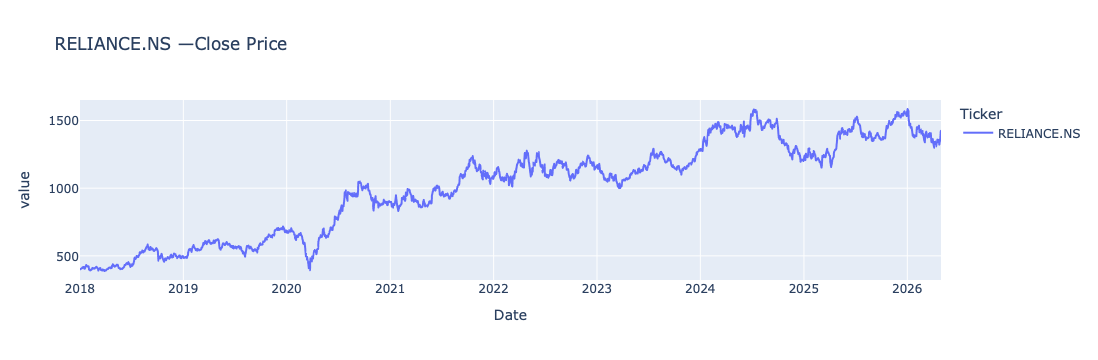

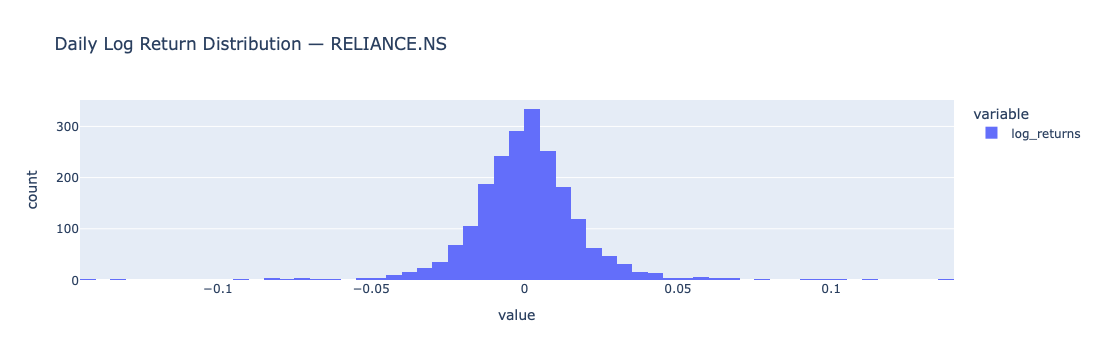

In [23]:
# Check 1 — mean should be small and positive (close to 0)
print(f"Mean daily return: {df['log_returns'].mean():.6f}")

# Check 2 — std should be between 0.01 and 0.03 for most NSE stocks
print(f"Daily std: {df['log_returns'].std():.4f}")

# Check 3 — kurtosis should be > 3 (fat tails — you'll reference this in your paper)
print(f"Kurtosis: {df['log_returns'].kurtosis():.2f}")

import plotly.express as px

# For price chart
fig = px.line(prices, title="RELIANCE.NS —Close Price")
fig.show()

# For return distribution
fig = px.histogram(df['log_returns'], nbins=100,
                   title="Daily Log Return Distribution — RELIANCE.NS")
fig.show()

In [9]:
log_returns = df['log_returns'].dropna() ##it is umportant to clean the data before calcualteing VAR

log_returns

Date
2018-01-02    0.001538
2018-01-03    0.003998
2018-01-04    0.005994
2018-01-05    0.003200
2018-01-08    0.005724
                ...   
2026-04-24   -0.011680
2026-04-27    0.028217
2026-04-28    0.016772
2026-04-29    0.025940
2026-04-30    0.003781
Name: log_returns, Length: 2055, dtype: float64


=====Historical VaR at different confidence levels=======
VaR (90 confidence): -0.0178 or -1.7801%
VaR (95 confidence): -0.0238 or -2.3850%
VaR (99 confidence): -0.0412 or -4.1217%


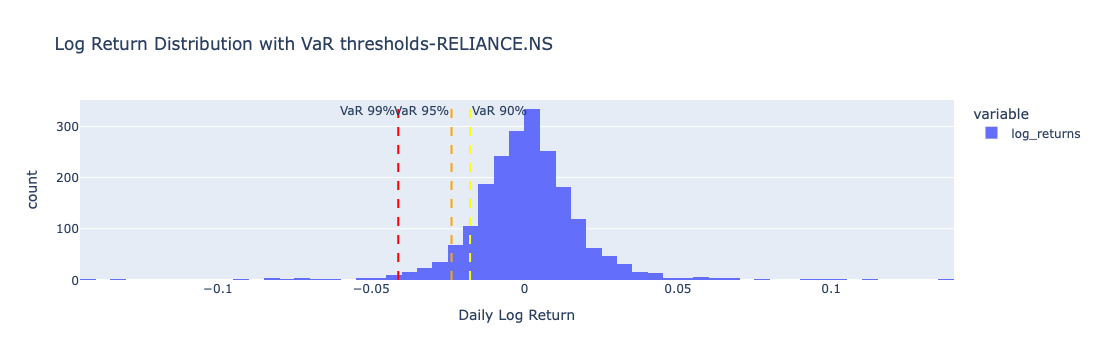


============ CALM VS CRISIS PERIOD HISTORICAL VAR 95%==============
var_calmperiod(2018-2019) is: -0.02 or -2.44%
var_crisisperiod(2020) is: -0.04 or -3.84%
Calm period worst single day: -0.07 or -7.12%
Crisis period worst single day: -0.14 or -14.10%

===========ROLLING VAR=========
Date
2018-01-02         NaN
2018-01-03         NaN
2018-01-04         NaN
2018-01-05         NaN
2018-01-08         NaN
                ...   
2026-04-24   -0.020555
2026-04-27   -0.020555
2026-04-28   -0.020555
2026-04-29   -0.020555
2026-04-30   -0.020555
Name: log_returns, Length: 2055, dtype: float64


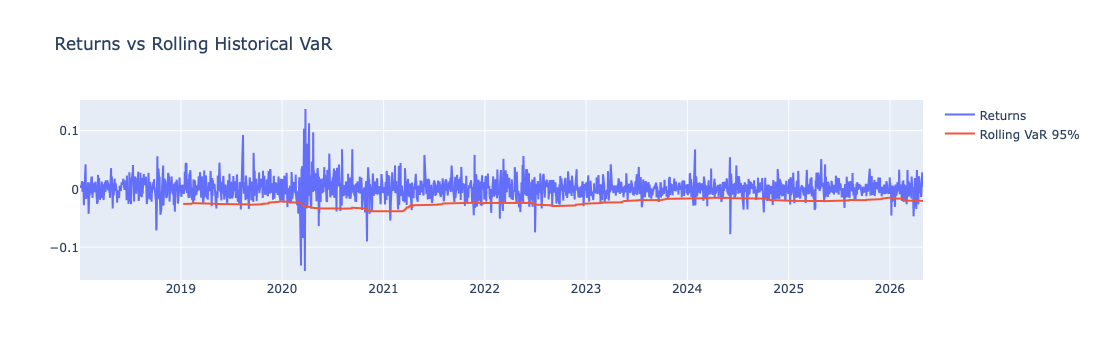

In [25]:
## DAY 2 HISTORICAL VAR
confidence_levels=[90,95,99]

print('\n=====Historical VaR at different confidence levels=======')
for cl in confidence_levels:
    percentile=(100-cl)
    var=np.percentile(log_returns,percentile)
    print(f"VaR ({cl} confidence): {var:.4f} or {var*100:.4f}%")

var_90=np.percentile(log_returns,10)
var_95=np.percentile(log_returns,5)
var_99=np.percentile(log_returns,1)

fig1=px.histogram(log_returns,nbins=100,title='Log Return Distribution with VaR thresholds-RELIANCE.NS',
                 labels={"value": "Daily Log Return", "count": "Frequency"})

fig1.add_vline(x=var_90, line_color="yellow", line_dash="dash",
              annotation_text="VaR 90%", annotation_position="top right")

fig1.add_vline(x=var_95, line_color="orange", line_dash="dash",
              annotation_text="VaR 95%", annotation_position="top left")

fig1.add_vline(x=var_99, line_color="red", line_dash="dash",
              annotation_text="VaR 99%", annotation_position="top left")
fig1.show()

# # Compare VaR estimated from a calm period vs a crisis period
print("\n============ CALM VS CRISIS PERIOD HISTORICAL VAR 95%==============")
calm_period=log_returns["2018-01-02":"2019-12-31"]  ## this is slicing concept 
crisis_period=log_returns["2020-01-01":"2020-12-31"]

#calucalte VaR at 95% confidence for these periods
var_calmperiod= np.percentile(calm_period,5)
var_crisisperiod=np.percentile(crisis_period,5)

print(f"var_calmperiod(2018-2019) is: {var_calmperiod:.2f} or {var_calmperiod*100:.2f}%")
print(f"var_crisisperiod(2020) is: {var_crisisperiod:.2f} or {var_crisisperiod*100:.2f}%")

print(f"Calm period worst single day: {calm_period.min():.2f} or {calm_period.min()*100:.2f}%")
print(f"Crisis period worst single day: {crisis_period.min():.2f} or {crisis_period.min()*100:.2f}%")

#Add a rolling VaR at 95% confidence

import plotly.graph_objects as go

window=252 # 1year trading period
rolling_var=log_returns.rolling(window).apply( lambda x: np.percentile(x,5))
print("\n===========ROLLING VAR=========")
print(rolling_var)

fig2=go.Figure()
fig2.add_trace(go.Scatter(x=log_returns.index,y=log_returns, name='Returns'))
fig2.add_trace(go.Scatter(x=rolling_var.index,y=rolling_var,name='Rolling VaR 95%'))
fig2.update_layout(title="Returns vs Rolling Historical VaR")
fig2.show()

In [15]:
# Note: in rolling var graphthe blue returns spike downward to -0.14, but the red VaR line only dips after the crash. 
#        That lag is the look-back bias made visible.

 ## What I learned — Historical VaR

# - Historical VaR at 95% = the 5th percentile of past returns (np.percentile, 5)
# - It makes ZERO distribution assumptions  just sorts actual past returns
# - Calm period VaR: -2.44% | Crisis period VaR: -3.84% | Gap: 57%
# - Worst calm day: -7.12% | Worst crisis day: -14.10%
# - Key weakness: VaR only rises AFTER the crash enters the rolling window
#   (visible in the Rolling VaR chart  red line lags the 2020 spike)
# - This lag:the model cannot warn you before a new crisis

In [17]:
#DAY 3 implementing the Parametric VaR 

#VaR=mu+sigma*Z where Z is the percentile of a standard normal distribution
# scipy.stats.norm.ppf gives you the percentile of a Normal distribution

import scipy.stats as stats

log_returns

mu= log_returns.mean()
sigma= log_returns.std()

confidence_levels=[0.90,0.95,0.99]

print("\n========= PARAMETRIC VaR========")
for cl in confidence_levels:
    
    parametric_var= mu+(sigma*stats.norm.ppf(1-cl))
    print(f"Parametric VaR at {cl}% : {parametric_var:.4f} or {parametric_var*100:.4f}%")

#comparision of historical and paramtric VaR

print("\nPARAMETRIC VaR vs HISTORICAL VaR — RELIANCE.NS")
print("=" * 55)
print(f"{'Confidence':>12} | {'Parametric VaR':>15} | {'Historical VaR':>15}")
print("=" * 55)

for cl in confidence_levels:
    var_parametric = mu + sigma * stats.norm.ppf(1 - cl)
    var_historical = np.percentile(log_returns, (1 - cl) * 100)
    print(f"{int(cl*100):>11}% | {var_parametric*100:>14.2f}% | {var_historical*100:>14.2f}%")

print("=" * 55)

# Generate a Normal distribution curve using your actual μ and σ
x = np.linspace(log_returns.min(), log_returns.max(), 300)
normal_curve = stats.norm.pdf(x, mu, sigma)

# Scale the normal curve to match histogram height
hist_counts, hist_bins = np.histogram(log_returns, bins=100)
scale_factor = hist_counts.max() / normal_curve.max()
normal_curve_scaled = normal_curve * scale_factor

fig3=go.Figure()
parametric_var95= mu+(sigma*stats.norm.ppf(0.05))

                      
fig3.add_trace(go.Histogram(x=log_returns,nbinsx=100,name="Log_returns"))
fig3.add_vline(x=parametric_var95,line_color="blue", line_dash="dash", annotation_text="Parametric VaR 95%", annotation_position="top left")
fig3.add_vline(x=var_95,line_color="red", line_dash="dash", annotation_text="VaR 95%", annotation_position="top right")

# Normal distribution overlay
fig3.add_trace(go.Scatter(
    x=x,
    y=normal_curve_scaled,
    mode='lines',
    name='Normal Distribution (assumed)',
    line=dict(color='red', width=2.5)
))


fig3.update_layout(
    title="Actual Returns vs Normal Distribution — Fat Tail Problem(RELIANCE.NS)",
    xaxis_title="Daily Log Return",
    yaxis_title="Frequency",
    barmode='overlay'
)
fig3.show()

calm_period = log_returns["2018-01-01":"2019-12-31"]
crisis_period = log_returns["2020-01-01":"2020-12-31"]

print("\nCALM vs CRISIS — Parametric VaR at 95%")
print("=" * 50)

for label, subset in [("Calm (2018–19)", calm_period), ("Crisis (2020)", crisis_period)]:
    mu_sub = subset.mean()
    sigma_sub = subset.std()
    var_param = mu_sub + sigma_sub * stats.norm.ppf(0.05)
    var_hist = np.percentile(subset, 5)
    print(f"\n{label}")
    print(f"  Parametric VaR 95%:  {var_param*100:.2f}%")
    print(f"  Historical VaR 95%:  {var_hist*100:.2f}%")
    print(f"  Difference:          {abs(var_param - var_hist)*100:.2f}%")



========= PARAMETRIC VaR========
Parametric VaR at 0.9% : -0.0218 or -2.1803%
Parametric VaR at 0.95% : -0.0282 or -2.8160%
Parametric VaR at 0.99% : -0.0401 or -4.0083%

PARAMETRIC VaR vs HISTORICAL VaR — RELIANCE.NS
  Confidence |  Parametric VaR |  Historical VaR
         90% |          -2.18% |          -1.78%
         95% |          -2.82% |          -2.38%
         99% |          -4.01% |          -4.12%



CALM vs CRISIS — Parametric VaR at 95%

Calm (2018–19)
  Parametric VaR 95%:  -2.66%
  Historical VaR 95%:  -2.44%
  Difference:          0.23%

Crisis (2020)
  Parametric VaR 95%:  -4.73%
  Historical VaR 95%:  -3.84%
  Difference:          0.89%


In [19]:
## Day 3 — Parametric VaR: What I Learned

# Formula: VaR = μ + σ × Z
# - μ = mean daily return (very close to 0)
# - σ = standard deviation of returns  
# - Z = stats.norm.ppf(0.05) = -1.645 at 95% confidence (fixed number from Normal distribution)

# Key assumption: Returns follow a Normal distribution
# Key weakness: They don't — real returns have fat tails (kurtosis > 3)

# Evidence from my chart:
# - Normal curve underestimates the height of the left tail bars
# - At 99% confidence, Parametric VaR < Historical VaR (Normal misses extreme losses)
# - During crisis, the gap between the two methods widens further

#NOTE:
# "Parametric VaR assumes returns are normally distributed and computes 
# VaR analytically using the mean and standard deviation. It's fast and 
# clean but underestimates tail losses because real returns have fat tails 
# kurtosis above 3. This is visible in the data: at 99% confidence, 
# Historical VaR shows larger losses than Parametric VaR because it 
# captures actual extreme days that the Normal distribution assigns near-zero probability to."

In [55]:
## Implementing CVaR

#cvar is the average of the extremes loses beyond the var threshold
## so we can write CVaR= return[returns<=var_threshold].mean()

confidence_levels= [0.90,0.95,0.99]

for cl in confidence_levels:
    var_threshold= np.percentile(log_returns,(1-cl)*100)
    cvar= log_returns[log_returns<=var_threshold].mean()
    print(f"CVaR at confidence level {cl*100}% - {cvar:.4f} or {cvar*100:.2f}%")
print("\n")
               
print("FULL COMPARISON — Historical VaR vs Parametric VaR vs CVaR")
print("=" * 70)
print(f"{'Confidence':>12} | {'Hist VaR':>10} | {'Param VaR':>10} | {'CVaR':>10} | {'VaR-CVaR Gap':>12}")
print("=" * 70)

for cl in confidence_levels:
    # Historical VaR
    var_hist = np.percentile(log_returns, (1 - cl) * 100)
    
    # Parametric VaR
    var_param = mu + sigma * stats.norm.ppf(1 - cl)
    
    # CVaR
    cvar = log_returns[log_returns <= var_hist].mean()
    
    # Gap
    gap = abs(cvar - var_hist)
    
    print(f"{int(cl*100):>11}% | {var_hist*100:>9.2f}% | {var_param*100:>9.2f}% | {cvar*100:>9.2f}% | {gap*100:>11.2f}%")

print("=" * 70)



CVaR at confidence level 90.0% - -0.0292 or -2.92%
CVaR at confidence level 95.0% - -0.0379 or -3.79%
CVaR at confidence level 99.0% - -0.0665 or -6.65%


FULL COMPARISON — Historical VaR vs Parametric VaR vs CVaR
  Confidence |   Hist VaR |  Param VaR |       CVaR | VaR-CVaR Gap
         90% |     -1.78% |     -2.18% |     -2.92% |        1.14%
         95% |     -2.38% |     -2.82% |     -3.79% |        1.41%
         99% |     -4.12% |     -4.01% |     -6.65% |        2.52%


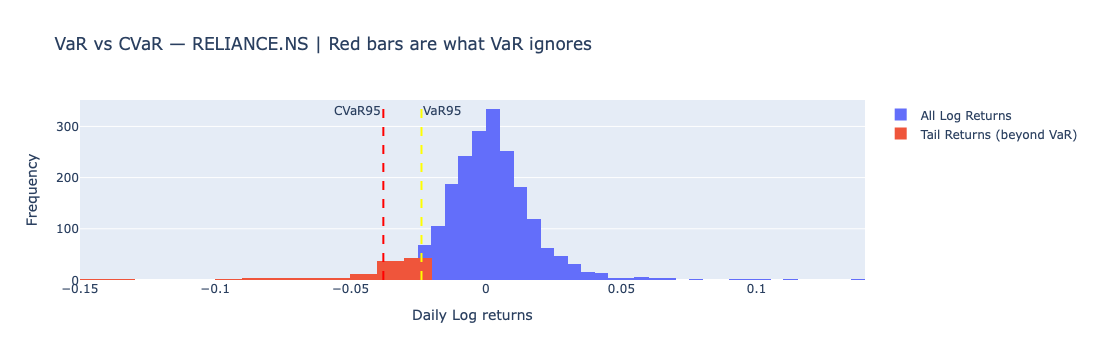


CALM vs CRISIS — VaR and CVaR at 95%

Calm (2018-19)
  Historical VaR 95%:  -2.44%
  CVaR 95%:            -3.39%
  VaR-CVaR Gap:        0.95%
  Worst single day:    -7.12%

Crisis (2020)
  Historical VaR 95%:  -3.84%
  CVaR 95%:            -6.87%
  VaR-CVaR Gap:        3.02%
  Worst single day:    -14.10%


In [21]:
#COMPARING visually VAR95% with CVAR 95%

var_95=np.percentile(log_returns,5)
cvar_95=log_returns[log_returns<=var_95].mean()

fig4=go.Figure()
fig4.add_trace(go.Histogram(x=log_returns,nbinsx=100,name='All Log Returns',))

tail_returns = log_returns[log_returns <= var_95]
fig4.add_trace(go.Histogram(
    x=tail_returns,
    nbinsx=20,
    name='Tail Returns (beyond VaR)',
    
))

fig4.add_vline(x=var_95,line_color="yellow",line_dash="dash",annotation_text="VaR95",annotation_position="top right")
fig4.add_vline(x=cvar_95,line_color="red",line_dash="dash",annotation_text="CVaR95",annotation_position="top left")

fig4.update_layout(title="VaR vs CVaR — RELIANCE.NS | Red bars are what VaR ignores", 
                   xaxis_title="Daily Log returns",
                   yaxis_title="Frequency",
                   barmode='overlay'
                  )
fig4.show()


#CALM PERIOD VS CRISIS PERIOD CVAR
calm_period = log_returns["2018-01-01":"2019-12-31"]
crisis_period = log_returns["2020-01-01":"2020-12-31"]

print("\nCALM vs CRISIS — VaR and CVaR at 95%")
print("=" * 55)

for label, subset in [("Calm (2018-19)", calm_period), ("Crisis (2020)", crisis_period)]:
    var = np.percentile(subset, 5)
    cvar = subset[subset <= var].mean()
    worst_day = subset.min()
    
    print(f"\n{label}")
    print(f"  Historical VaR 95%:  {var*100:.2f}%")
    print(f"  CVaR 95%:            {cvar*100:.2f}%")
    print(f"  VaR-CVaR Gap:        {abs(cvar-var)*100:.2f}%")
    print(f"  Worst single day:    {worst_day*100:.2f}%")


In [ ]:
## CVaR: What I Learned

# Formula: CVaR = mean of all returns where return ≤ VaR threshold
# Code: log_returns[log_returns <= var_threshold].mean()

# What VaR tells you: The minimum loss on your worst 5% of days (just the threshold)
# What CVaR tells you: The average loss on your worst 5% of days (the full severity)

# Key insight:
# - VaR tells you where the tail begins
# - CVaR tells you how bad the tail actually is
# - A large VaR-CVaR gap = fat, dangerous tail

# Evidence from my data:
# - Calm period VaR-CVaR gap: 0.95%
# - Crisis period VaR-CVaR gap: 3.02%
# - Gap widens during crisis = tail gets fatter under stress

# Why Basel III mandates CVaR over VaR:
# VaR could show two portfolios as equally risky when one has catastrophic 
# losses hiding beyond the threshold. CVaR captures those catastrophic losses.


# CVaR, or Conditional Value at Risk, answers a question VaR cannot 
# given that I'm in the worst 5% of days, what is my average loss? 
# I implement it as the mean of all returns below the VaR threshold. 
# On Reliance data, the crisis period gap between VaR and CVaR was 
# significantly larger than the calm period, proving the crisis tail 
# was not just lower but fatter  with extreme losses VaR would have 
# completely missed.

In [91]:
# Compare all three methods on one stock, print clean summary table

def compute_risk_metrics(ticker,start='2018-01-01',end='2026-05-01'):
    data=yf.download(ticker,start=start,end=end,progress=False)

    # Fix: Safely handle multi-index structure from yfinance
    if isinstance(data.columns, pd.MultiIndex):
        price = data["Close"][ticker]
    else:
        price = data["Close"]
    
    log_returns=np.log(price/price.shift(1)).dropna()

    mu=log_returns.mean()
    sigma=log_returns.std()

    confidence_levels=[0.90,0.95,0.99]
    results=[]

    for cl in confidence_levels:
        hs_var=np.percentile(log_returns,(1-cl)*100)
        param_var=mu+(sigma*stats.norm.ppf(1-cl))
        cvar=log_returns[log_returns<=hs_var].mean()
        
        results.append({
            'Ticker': ticker,
            'Confidence': f"{int(cl*100)}%",
            'Historical VaR': f"{hs_var*100:.2f}%",
            'Parametric VaR': f"{param_var*100:.2f}%",
            'CVaR': f"{cvar*100:.2f}%",
            'VaR-CVaR Gap': f"{abs(cvar - hs_var)*100:.2f}%"
        })
    return pd.DataFrame(results), log_returns

reliance_df, reliance_returns = compute_risk_metrics("RELIANCE.NS")

print("\nRISK METRICS SUMMARY — RELIANCE.NS")
print("=" * 75)
print(reliance_df.to_string(index=False))
print("=" * 75)


# Distribution statistics — tells the fat tail story
mu = reliance_returns.mean()
sigma = reliance_returns.std()
skewness = reliance_returns.skew()
kurtosis = reliance_returns.kurtosis() + 3  # +3 to convert to raw kurtosis

print("\nDISTRIBUTION STATISTICS — RELIANCE.NS")
print("=" * 40)
print(f"  Mean daily return:   {mu*100:.4f}%")
print(f"  Std deviation:       {sigma*100:.4f}%")
print(f"  Skewness:            {skewness:.4f}")
print(f"  Kurtosis:            {kurtosis:.4f}")
print(f"  Worst single day:    {reliance_returns.min()*100:.2f}%")
print(f"  Best single day:     {reliance_returns.max()*100:.2f}%")
print("=" * 40)

if kurtosis > 3:
    print(f"\n  ⚠ Kurtosis = {kurtosis:.2f} > 3 — Fat tails confirmed.")
    print("  Normal distribution assumption is invalid for this stock.")




RISK METRICS SUMMARY — RELIANCE.NS
     Ticker Confidence Historical VaR Parametric VaR   CVaR VaR-CVaR Gap
RELIANCE.NS        90%         -1.78%         -2.18% -2.92%        1.14%
RELIANCE.NS        95%         -2.38%         -2.82% -3.79%        1.41%
RELIANCE.NS        99%         -4.12%         -4.01% -6.65%        2.52%

DISTRIBUTION STATISTICS — RELIANCE.NS
  Mean daily return:   0.0618%
  Std deviation:       1.7496%
  Skewness:            0.0461
  Kurtosis:            12.1324
  Worst single day:    -14.10%
  Best single day:     13.73%

  ⚠ Kurtosis = 12.13 > 3 — Fat tails confirmed.
  Normal distribution assumption is invalid for this stock.


/var/folders/j2/gw4b0qqs0q1fvcyp3bj_6f8r0000gn/T/ipykernel_16383/3919938373.py:4: FutureWarning:

YF.download() has changed argument auto_adjust default to True



/var/folders/j2/gw4b0qqs0q1fvcyp3bj_6f8r0000gn/T/ipykernel_16383/903097354.py:4: FutureWarning:

YF.download() has changed argument auto_adjust default to True

/var/folders/j2/gw4b0qqs0q1fvcyp3bj_6f8r0000gn/T/ipykernel_16383/903097354.py:4: FutureWarning:

YF.download() has changed argument auto_adjust default to True

/var/folders/j2/gw4b0qqs0q1fvcyp3bj_6f8r0000gn/T/ipykernel_16383/903097354.py:4: FutureWarning:

YF.download() has changed argument auto_adjust default to True

/var/folders/j2/gw4b0qqs0q1fvcyp3bj_6f8r0000gn/T/ipykernel_16383/903097354.py:4: FutureWarning:

YF.download() has changed argument auto_adjust default to True

/var/folders/j2/gw4b0qqs0q1fvcyp3bj_6f8r0000gn/T/ipykernel_16383/903097354.py:4: FutureWarning:

YF.download() has changed argument auto_adjust default to True

/var/folders/j2/gw4b0qqs0q1fvcyp3bj_6f8r0000gn/T/ipykernel_16383/3377219861.py:26: FutureWarning:

YF.download() has changed argument auto_adjust default to True

/var/folders/j2/gw4b0qqs0q1fvcyp


===========RELIANCE.NS Results===========
        Ticker Confidence Historical VaR Parametric VaR    CVaR VaR-CVaR Gap
0  RELIANCE.NS        90%         -1.78%         -2.18%  -2.92%        1.14%
1  RELIANCE.NS        95%         -2.38%         -2.82%  -3.79%        1.41%
2  RELIANCE.NS        99%         -4.12%         -4.01%  -6.65%        2.52%

===========TCS.NS Results===========
   Ticker Confidence Historical VaR Parametric VaR    CVaR VaR-CVaR Gap
0  TCS.NS        90%         -1.61%         -1.91%  -2.70%        1.09%
1  TCS.NS        95%         -2.27%         -2.46%  -3.51%        1.24%
2  TCS.NS        99%         -4.23%         -3.50%  -5.70%        1.47%

===========HDFCBANK.NS Results===========
        Ticker Confidence Historical VaR Parametric VaR    CVaR VaR-CVaR Gap
0  HDFCBANK.NS        90%         -1.49%         -1.93%  -2.67%        1.17%
1  HDFCBANK.NS        95%         -2.20%         -2.48%  -3.54%        1.34%
2  HDFCBANK.NS        99%         -3.85%         

/var/folders/j2/gw4b0qqs0q1fvcyp3bj_6f8r0000gn/T/ipykernel_16383/3377219861.py:26: FutureWarning:

YF.download() has changed argument auto_adjust default to True

/var/folders/j2/gw4b0qqs0q1fvcyp3bj_6f8r0000gn/T/ipykernel_16383/3377219861.py:26: FutureWarning:

YF.download() has changed argument auto_adjust default to True

/var/folders/j2/gw4b0qqs0q1fvcyp3bj_6f8r0000gn/T/ipykernel_16383/3377219861.py:26: FutureWarning:

YF.download() has changed argument auto_adjust default to True



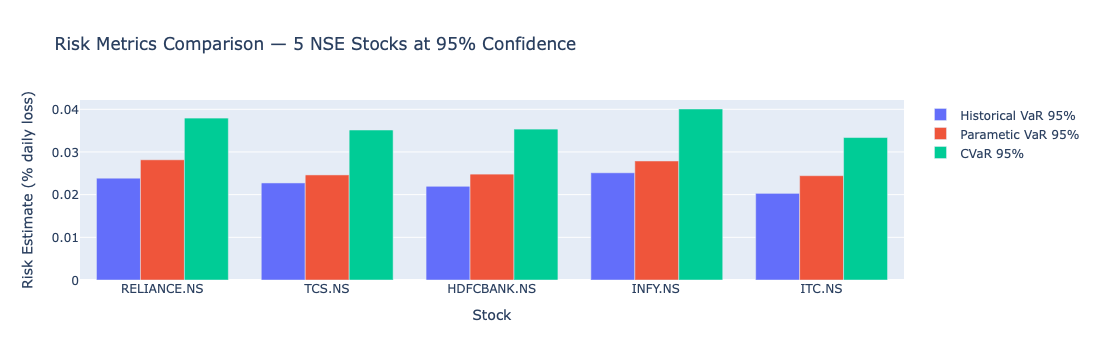

In [87]:
# Extending to 5 stocks
# 5 liquid NSE stocks across different sectors
stocks = {
    "RELIANCE.NS": "Reliance Industries (Energy)",
    "TCS.NS": "Tata Consultancy Services (IT)",
    "HDFCBANK.NS": "HDFC Bank (Banking)",
    "INFY.NS": "Infosys (IT)",
    "ITC.NS": "ITC Limited (FMCG)"
}

for stock in stocks:
    stock_result,stock_returns=compute_risk_metrics(stock)

    print(f"\n==========={stock} Results===========")
    print(stock_result)


#Comparing hs var,param var and cvar across all 5 stock at 95% confidence level on a graph

tickers=[]
hvar95=[]
pvar95=[]
cvar95=[]

for stock in stocks:
    data=yf.download(stock,start='2018-01-01',end='2026-05-01',progress=False)

    price = data["Close"].squeeze() ##IMP TO ADD squeeze
    
    log_returns=np.log(price/price.shift(1)).dropna()

    mu=log_returns.mean()
    sigma=log_returns.std()
    hsvar=np.percentile(log_returns,5)
    pvar=mu+(sigma*stats.norm.ppf(0.05))
    cvar=log_returns[log_returns<=hsvar].mean()
    
    tickers.append(stock)
    hvar95.append(abs(hsvar))
    pvar95.append(abs(pvar))
    cvar95.append(abs(cvar))

# print("Tickers:", tickers)
# print("Hist VaR:", hvar95)
# print("Param VaR:", pvar95)
# print("CVaR:", cvar95)
    
fig5=go.Figure()

fig5.add_trace(go.Bar(name='Historical VaR 95%',
    x=tickers,
    y=hvar95,
))
fig5.add_trace(go.Bar(name='Parametic VaR 95%',
    x=tickers,
    y=pvar95,
))
fig5.add_trace(go.Bar(name='CVaR 95%',
    x=tickers,
    y=cvar95,
))

fig5.update_layout(
    title='Risk Metrics Comparison — 5 NSE Stocks at 95% Confidence',
    xaxis_title='Stock',
    yaxis_title='Risk Estimate (% daily loss)',
    barmode='group'
)